# 1.Twitter GRAPH CONSTRUCTION

POST-POST HOMOPHILY GRAPH

In [1]:
import pandas as pd
import networkx as nx
from itertools import combinations

# =====================================================
# LOAD TWITTER GRAPH DATASET
# =====================================================

df = pd.read_csv(
    "../../data_preprocess/processed_data/graph_data/twitter_graph.csv"
)

print("=" * 60)
print("TWITTER GRAPH DATA")
print("=" * 60)

print(df.shape)

TWITTER GRAPH DATA
(44676, 30)


In [ ]:
import pandas as pd
import numpy as np
import time

overall_start = time.time()

# =====================================================
# 1. GENERATE NODES
# =====================================================
print("Đang tạo Nodes cho Twitter...")
nodes_df = df.copy().rename(columns={"post_id": "Id"})
nodes_df["Label"] = nodes_df["Id"]
nodes_df.to_csv("twitter_node.csv", index=False, encoding='utf-8')

# =====================================================
# 2. GENERATE EDGES (TWITTER POWER & DEBATE GRAPH)
# =====================================================
edges_list = []


sorted_df = df.sort_values(by=['followers'], ascending=True)

# --- A. TOPIC - POLITICS, CLIMATE, FINANCE---
if 'topic' in sorted_df.columns:
    print("Processing Twitter Debate Hubs (Politics, Climate, Finance)...")
    for topic, group in sorted_df.groupby('topic'):
        if pd.isna(topic): continue
        ids = group['post_id'].values
        if len(ids) < 2: continue
        
        for i in range(len(ids) - 1):
            weight = 2.0 if topic in ['Politics', 'Climate', 'Finance'] else 1.2
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": weight, 
                "Relation": "topic_debate"
            })

# --- B. Language & location (KOREAN, FRENCH, EUROPE) ---
cat_features = ['language', 'location']
for feat in cat_features:
    if feat not in sorted_df.columns: continue
    print(f"Processing Twitter Global Clusters: {feat}...")
    for val, group in sorted_df.groupby(feat):
        ids = group['post_id'].values
        if len(ids) < 2: continue
        for i in range(len(ids) - 1):
            #  Korean, French và Europe theo Baseline
            weight = 1.5 if val in ['Korean', 'French', 'Europe'] else 1.0
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": weight, 
                "Relation": feat
            })

# --- C. MEDIA TYPE POLL (TOP FEATURE) ---
if 'media_type' in sorted_df.columns:
    print("Processing Twitter Poll Engagement...")
    poll_group = sorted_df[sorted_df['media_type'] == 'Poll']
    ids = poll_group['post_id'].values
    if len(ids) >= 2:
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 1.4, 
                "Relation": "poll_connection"
            })

# --- D. TOXICITY & SENTIMENT (DEBATE VIBE) ---
# Toxicity_score and sentiment are both in the Top 10 features.
if 'toxicity_score' in sorted_df.columns:
    print("Processing Twitter Toxicity Echo Chambers...")
    temp_df = sorted_df.copy()
    temp_df['toxic_bins'] = temp_df['toxicity_score'].apply(lambda x: round(x/10)*10)
    for val, group in temp_df.groupby('toxic_bins'):
        ids = group['post_id'].values
        if len(ids) < 2: continue
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 1.1, 
                "Relation": "toxic_vibe"
            })

# --- E. SAME AUTHOR - THREADS ---
print("Processing Twitter Threads (Author Bridges)...")
for user_id, group in sorted_df.groupby('user_id'):
    ids = group['post_id'].values
    if len(ids) >= 2:
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 2.5, 
                "Relation": "same_author"
            })

# =====================================================
# 3. CLEAN & EXPORT
# =====================================================
edges_df = pd.DataFrame(edges_list)
if not edges_df.empty:
    edges_df[['Source', 'Target']] = np.sort(edges_df[['Source', 'Target']], axis=1)
    edges_df = edges_df.drop_duplicates(subset=['Source', 'Target', 'Relation'])
    edges_df = edges_df[edges_df['Source'] != edges_df['Target']]

edges_df.to_csv("twitter_edge.csv", index=False, encoding='utf-8')

print(f"\n---  TWITTER GRAPH ---")
print(f"Nodes: {len(nodes_df):,}")
print(f"Edges: {len(edges_df):,}")
print(f"Time: {round(time.time() - overall_start, 2)}s")

Đang tạo Nodes cho Twitter...
Processing Twitter Debate Hubs (Politics, Climate, Finance)...
Processing Twitter Global Clusters: language...
Processing Twitter Global Clusters: location...
Processing Twitter Poll Engagement...
Processing Twitter Toxicity Echo Chambers...
Processing Twitter Threads (Author Bridges)...

---  TWITTER GRAPH ---
Nodes: 44,676
Edges: 182,745
Time: 4.4s


In [80]:
import pandas as pd

graph_df = pd.read_csv(
    "twitter-result.csv"
)

print("\n" + "=" * 60)
print("GRAPH FEATURES DATA")
print("=" * 60)

print(graph_df.shape)

print("\nColumns:")
print(graph_df.columns.tolist())


GRAPH FEATURES DATA
(44676, 45)

Columns:
['Id', 'Label', 'platform', 'hour_of_day', 'day_of_week', 'is_weekend', 'user_id', 'followers', 'account_age_days', 'verified', 'topic', 'language', 'content_length', 'media_type', 'num_hashtags', 'sentiment_category', 'sentiment_positive', 'sentiment_negative', 'sentiment_neutral', 'toxicity_score', 'location', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'has_media', 'many_hashtags', 'long_content', 'sentiment_intensity', 'high_toxicity', 'popularity', 'Degree', 'Eccentricity', 'closnesscentrality', 'harmonicclosnesscentrality', 'betweenesscentrality', 'Authority', 'Hub', 'pageranks', 'modularity_class', 'stat_inf_class', 'clustering', 'triangles', 'eigencentrality', 'componentnumber']


In [81]:
# SELECT ONLY USEFUL GRAPH FEATURES
# =====================================================

graph_features = graph_df[[
    "Id",
    "closnesscentrality", 
    "modularity_class", 
    "eigencentrality"
]]
graph_features = graph_features.rename(
    columns={
        "Id": "post_id"
    }
)

print("\nGraph Features Shape:")
print(graph_features.shape)



Graph Features Shape:
(44676, 4)


In [82]:
original_df = df.copy()

# =====================================================
# REMOVE DUPLICATES
# =====================================================

original_df = original_df.drop_duplicates(
    subset=["post_id"]
)

In [83]:
# MERGE POST_ID BACK TO TRAIN/TEST
# =====================================================
# We need mapping between rows
# =====================================================

# recreate metadata version
metadata_df = original_df.copy()

remove_cols = [
    
    "timestamp",
    "date",
    "platform",
    "likes",
    "shares",
    "comments",
    "views",
    "total_engagement",
    "engagement_rate_per_1k_followers",
    "viral_coefficient",
    "cross_platform_spread",
    "hours_since_post"
]

existing_remove_cols = [

    col for col in remove_cols
    if col in metadata_df.columns
]

metadata_df = metadata_df.drop(
    columns=existing_remove_cols
)


In [84]:
# =====================================================
# ONE-HOT ENCODING
# =====================================================

categorical_cols = [

    "topic",
    "language",
    "media_type",
    "sentiment_category",
    "location"
]

existing_categorical_cols = [

    col for col in categorical_cols
    if col in metadata_df.columns
]

metadata_df = pd.get_dummies(

    metadata_df,

    columns=existing_categorical_cols,

    drop_first=True
)


In [85]:
# LOAD FACEBOOK TRAIN / TEST
# =====================================================

train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/twitter_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/twitter_test.csv"
)

print("=" * 60)
print("METADATA DATASETS")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

METADATA DATASETS
Train Shape: (35740, 56)
Test Shape : (8936, 56)


In [86]:
# MERGE TRAIN
# =====================================================

train_hybrid = train_df.merge(

    graph_features,

    on="post_id",
    how="left"
)

# =====================================================
# MERGE TEST
# =====================================================

test_hybrid = test_df.merge(

    graph_features,

    on="post_id",
    how="left"
)

In [87]:

print("\n" + "="*30)
print("Class distribution in the training set")
print("="*30)
print(train_df["popularity"].value_counts())
print("\nTỷ lệ %:")
print(train_df["popularity"].value_counts(normalize=True) * 100)

print("\n" + "="*30)
print("Class distribution in the test set")
print("="*30)
print(test_df["popularity"].value_counts())
print("\nTỷ lệ %:")
print(test_df["popularity"].value_counts(normalize=True) * 100)


Class distribution in the training set
popularity
0    28550
1     7190
Name: count, dtype: int64

Tỷ lệ %:
popularity
0    79.882485
1    20.117515
Name: proportion, dtype: float64

Class distribution in the test set
popularity
0    7138
1    1798
Name: count, dtype: int64

Tỷ lệ %:
popularity
0    79.879141
1    20.120859
Name: proportion, dtype: float64


In [88]:

negative_count = train_df["popularity"].value_counts()[0]
positive_count = train_df["popularity"].value_counts()[1]

ratio = negative_count / positive_count
print(f"Class imbalance detected! scale_pos_weight = {ratio:.2f}")

Class imbalance detected! scale_pos_weight = 3.97


In [89]:
# FILL MISSING VALUES IN GRAPH FEATURES
# =====================================================

numeric_graph_cols = [
    "closnesscentrality", 
    "modularity_class", 
    "eigencentrality"
    
]

existing_numeric_cols = [col for col in numeric_graph_cols if col in train_hybrid.columns]

train_hybrid[existing_numeric_cols] = train_hybrid[existing_numeric_cols].fillna(0)
test_hybrid[existing_numeric_cols]  = test_hybrid[existing_numeric_cols].fillna(0)

X_train_cols = train_hybrid.columns
test_hybrid = test_hybrid.reindex(columns=X_train_cols, fill_value=0)

print("\n" + "=" * 60)
print("HYBRID DATASETS - CLEANED & ALIGNED")
print("=" * 60)
print(f"Train Hybrid: {train_hybrid.shape}")
print(f"Test Hybrid : {test_hybrid.shape}")


HYBRID DATASETS - CLEANED & ALIGNED
Train Hybrid: (35740, 59)
Test Hybrid : (8936, 59)


In [90]:
# SAVE HYBRID DATASETS
# =====================================================

train_hybrid.to_csv(
    "twitter_hybrid_train.csv",
    index=False
)

test_hybrid.to_csv(
    "twitter_hybrid_test.csv",
    index=False
)

In [91]:
# =====================================================
# INSTAGRAM HYBRID MODEL
# METADATA + GRAPH FEATURES
# =====================================================

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [92]:
# LOAD HYBRID DATASETS
# =====================================================

train_df = pd.read_csv(
    "twitter_hybrid_train.csv"
)

test_df = pd.read_csv(
    "twitter_hybrid_test.csv"
)

print("=" * 60)
print("HYBRID DATASETS")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

HYBRID DATASETS
Train Shape: (35740, 59)
Test Shape : (8936, 59)


In [93]:
# DROP ID COLUMNS
# =====================================================

drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_df.columns
]

train_df = train_df.drop(
    columns=existing_drop_cols
)

test_df = test_df.drop(
    columns=existing_drop_cols
)

In [94]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_df.drop(
    columns=["popularity"]
)

y_train = train_df["popularity"]

X_test = test_df.drop(
    columns=["popularity"]
)

y_test = test_df["popularity"]

print("\nX_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)


X_train Shape: (35740, 56)
X_test Shape : (8936, 56)


In [95]:
from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     # Handle imbalanced data
    n_estimators=500,           # Number of boosting rounds
    learning_rate=0.02,         # Step size shrinkage
    max_depth=6,                # Maximum tree depth
    min_child_weight=1,         # Minimum sum of instance weight
    gamma=0.1,                  # Minimum loss reduction
    subsample=0.8,              # Fraction of training data per tree
    colsample_bytree=0.5,       # Fraction of features per tree
    random_state=42,            # For reproducibility
    n_jobs=-1                   # Use all CPU cores
)

In [96]:
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING HYBRID MODEL...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)


TRAINING HYBRID MODEL...


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [97]:
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [98]:
# EVALUATION
# =====================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [99]:
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)

print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.95      0.80      0.87      7138
           1       0.51      0.82      0.63      1798

    accuracy                           0.80      8936
   macro avg       0.73      0.81      0.75      8936
weighted avg       0.86      0.80      0.82      8936

ROC-AUC  : 0.8928


In [100]:
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


CONFUSION MATRIX
[[5705 1433]
 [ 325 1473]]


In [101]:
# FEATURE IMPORTANCE
# =====================================================

importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(20)
)


TOP 20 IMPORTANT FEATURES
                   feature  importance
3                followers    0.261625
5                 verified    0.113734
54        modularity_class    0.097806
40         language_Korean    0.013023
36         language_French    0.012923
29          topic_Politics    0.012003
28            topic_Health    0.011948
44         media_type_Poll    0.011832
18     sentiment_intensity    0.011308
22         topic_Education    0.011252
41     language_Portuguese    0.011216
6           content_length    0.011193
55         eigencentrality    0.011176
9       sentiment_negative    0.011122
10          toxicity_score    0.010914
4         account_age_days    0.010858
53      closnesscentrality    0.010758
51  location_South America    0.010733
39       language_Japanese    0.010714
48         location_Europe    0.010651


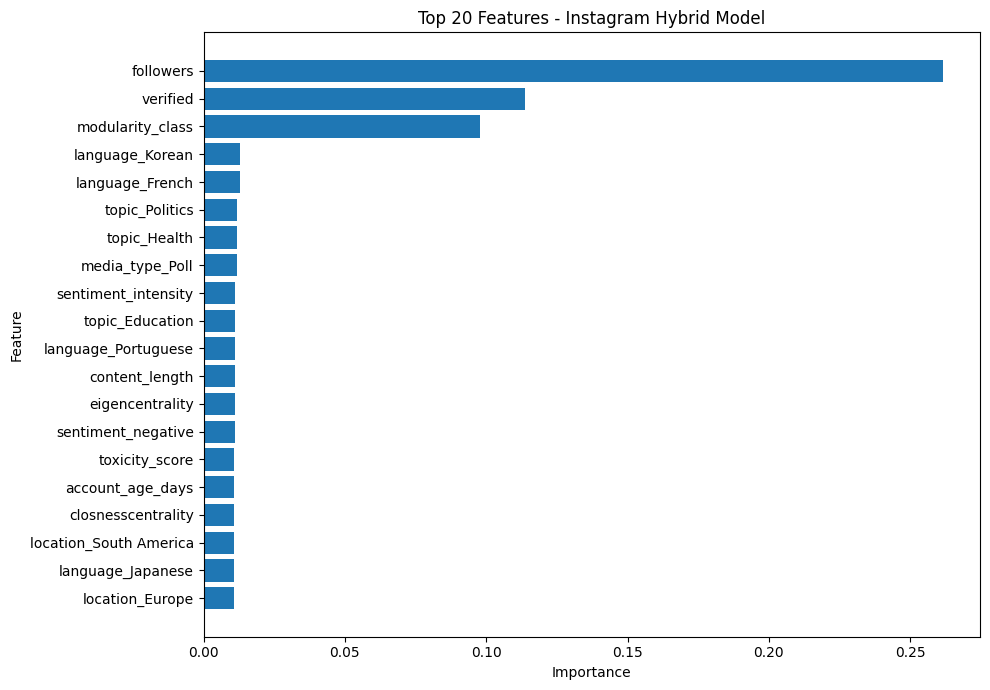

In [ ]:
# PLOT TOP FEATURES
# =====================================================
import matplotlib.pyplot as plt

top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 20 Features - Twitter Hybrid Model"
)

plt.tight_layout()

plt.show()

# 2. FACEBOOK NODE2VEC

 GRAPH EMBEDDING

In [104]:
import pandas as pd
import os
import networkx as nx

import time

start_time = time.time()

# 1. Just load edges, nodes
# =====================================================
print("Loading Edges file...")
edges_df = pd.read_csv("twitter_edge.csv") 

# 2. Building NetworkX Graph...
# =====================================================
print("Building NetworkX Graph...")
G = nx.from_pandas_edgelist(
    edges_df, 
    source="Source", 
    target="Target", 
    create_using=nx.Graph() 
)

print(f"Graph Created  | Nodes: {G.number_of_nodes():,} | Edges: {G.number_of_edges():,}")


print("TRAINING NODE2VEC (MULTI-CORE)...")


so_loi_cpu = os.cpu_count()
print(f" Your laptop has {so_loi_cpu} CPU cores. Mobilizing all cores... " )

print("\n" + "=" * 60)
print("TRAINING NODE2VEC (MULTI-CORE UPDATE)...")
print("=" * 60)



Loading Edges file...
Building NetworkX Graph...
Graph Created  | Nodes: 44,676 | Edges: 162,658
TRAINING NODE2VEC (MULTI-CORE)...
 Your laptop has 16 CPU cores. Mobilizing all cores... 

TRAINING NODE2VEC (MULTI-CORE UPDATE)...


In [105]:
from node2vec import Node2Vec
import time

node2vec = Node2Vec(
    G,
    dimensions=8,        
    walk_length=10,      
    num_walks=20,        
    workers=so_loi_cpu,  
    seed=42,
    quiet=False          
)

model = node2vec.fit(
    window=5, 
    min_count=1, 
    batch_words=4     
)

print("\nNode2Vec done")

print(f"\nNode2Vec done after: {round((time.time() - start_time)/60, 2)} minutes ")



Computing transition probabilities:   0%|          | 0/44676 [00:00<?, ?it/s]


Node2Vec done

Node2Vec done after: 26.26 minutes 


In [106]:
# 4.Split and save vectors 
# =====================================================
print("Exporting Embeddings to DataFrame...")

node_ids = list(model.wv.index_to_key)
embeddings = model.wv.vectors

emb_df = pd.DataFrame(embeddings, columns=[f"emb_{i}" for i in range(8)])
emb_df["post_id"] = node_ids 

emb_df = emb_df[emb_df['post_id'].astype(str).str.startswith('TWI')]


emb_df.to_csv("twitter_node2vec_8dims.csv", index=False)
print(f"Successfully saved {len(emb_df)} vectors of Post articles!")

Exporting Embeddings to DataFrame...
Successfully saved 44676 vectors of Post articles!


In [107]:
# TWITTER NODE2VEC HYBRID MODEL
# METADATA + NODE2VEC EMBEDDINGS
# =====================================================

import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

import matplotlib.pyplot as plt

In [108]:
# LOAD TRAIN / TEST DATA
# =====================================================

train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/twitter_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/twitter_test.csv"
)

print("=" * 60)
print("METADATA DATA")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

METADATA DATA
Train Shape: (35740, 56)
Test Shape : (8936, 56)


In [109]:
#LOAD NODE2VEC EMBEDDINGS
# =====================================================

embedding_df = pd.read_csv(
    "twitter_node2vec_8dims.csv"
)

print("\n" + "=" * 60)
print("NODE2VEC EMBEDDINGS")
print("=" * 60)

print(embedding_df.shape)

print("\nEmbedding Columns:")
print(embedding_df.columns[:10])


NODE2VEC EMBEDDINGS
(44676, 9)

Embedding Columns:
Index(['emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7',
       'post_id'],
      dtype='object')


In [110]:
# MERGE TRAIN
# =====================================================

train_hybrid = train_df.merge(

    embedding_df,

    on="post_id",
    how="left"
)

# =====================================================
# MERGE TEST
# =====================================================

test_hybrid = test_df.merge(

    embedding_df,

    on="post_id",
    how="left"
)

# =====================================================
# CHECK MISSING VALUES
# =====================================================

print("\n" + "=" * 60)
print("MISSING EMBEDDINGS CHECK")
print("=" * 60)

embedding_cols = [

    col for col in embedding_df.columns
    if col.startswith("n2v_")
]

print("\nTrain Missing:")

print(
    train_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

print("\nTest Missing:")

print(
    test_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

# =====================================================
# FILL MISSING EMBEDDINGS
# =====================================================

train_hybrid[embedding_cols] = train_hybrid[
    embedding_cols
].fillna(0)

test_hybrid[embedding_cols] = test_hybrid[
    embedding_cols
].fillna(0)

# =====================================================
# DROP ID COLUMNS
# =====================================================

drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_hybrid.columns
]

train_hybrid = train_hybrid.drop(
    columns=existing_drop_cols
)

test_hybrid = test_hybrid.drop(
    columns=existing_drop_cols
)


MISSING EMBEDDINGS CHECK

Train Missing:
0.0

Test Missing:
0.0


In [111]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_hybrid.drop(
    columns=["popularity"]
)

y_train = train_hybrid["popularity"]

X_test = test_hybrid.drop(
    columns=["popularity"]
)

y_test = test_hybrid["popularity"]

print("\n" + "=" * 60)
print("FINAL DATA")
print("=" * 60)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)



FINAL DATA
X_train: (35740, 61)
X_test : (8936, 61)


In [112]:
# =====================================================
# XGBOOST MODEL

from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    
    scale_pos_weight=ratio,      
   
    n_estimators=300,            
    learning_rate=0.05,          
    max_depth=5,                
    subsample=0.8,               
    colsample_bytree=0.5,        
    colsample_bylevel=0.5,
    reg_alpha=1.0,               
    reg_lambda=2.0,              
    random_state=42,
    n_jobs=-1
)
# =====================================================
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING NODE2VEC HYBRID MODEL...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)

print("Training completed ")

# =====================================================
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

# =====================================================
# EVALUATION
# =====================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


TRAINING NODE2VEC HYBRID MODEL...
Training completed 


In [113]:
# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.95      0.80      0.87      7138
           1       0.50      0.82      0.62      1798

    accuracy                           0.80      8936
   macro avg       0.72      0.81      0.74      8936
weighted avg       0.86      0.80      0.82      8936

ROC-AUC  : 0.8924


In [114]:
# FEATURE IMPORTANCE
# =====================================================

importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(20)
)


TOP 20 IMPORTANT FEATURES
               feature  importance
3            followers    0.329569
5             verified    0.083286
53               emb_0    0.022988
60               emb_7    0.021036
58               emb_5    0.019037
55               emb_2    0.016785
54               emb_1    0.016350
59               emb_6    0.016061
56               emb_3    0.015487
57               emb_4    0.014653
25       topic_Finance    0.012611
48     location_Europe    0.011649
17        long_content    0.011432
27        topic_Gaming    0.011122
9   sentiment_negative    0.010987
40     language_Korean    0.010870
6       content_length    0.010582
8   sentiment_positive    0.010396
29      topic_Politics    0.010193
44     media_type_Poll    0.010164


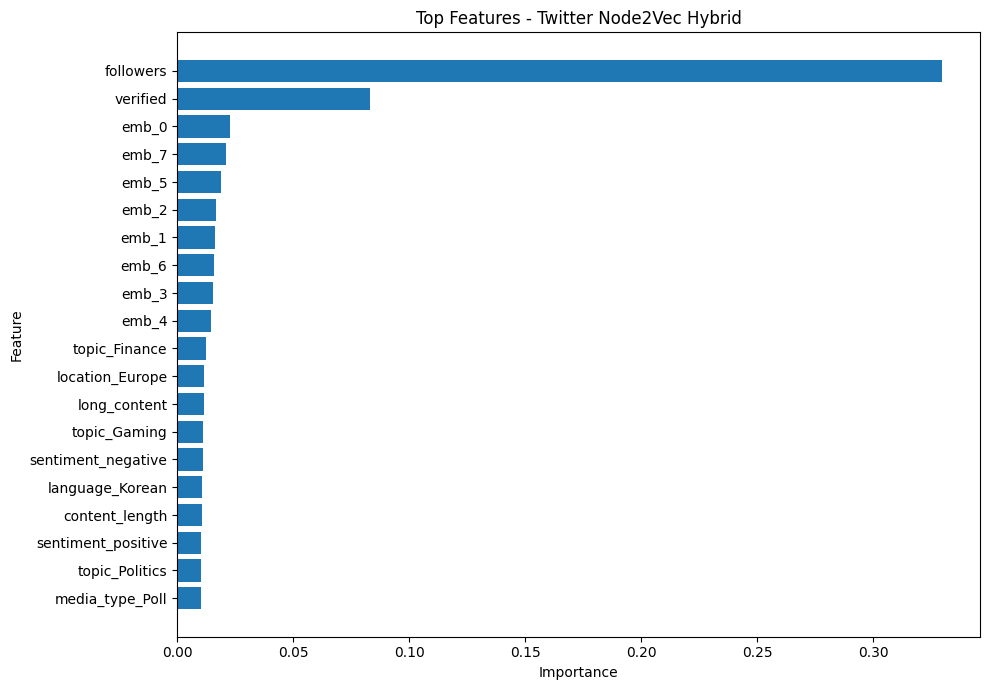

In [115]:
# =====================================================

top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top Features - Twitter Node2Vec Hybrid"
)

plt.tight_layout()

plt.show()

# 3. Facebook graph + Node2vector

In [116]:
selected_n2v = ["emb_2", "emb_7", "emb_4", "emb_0", "emb_6", "emb_5", "emb_3", "emb_1"]

embedding_df_filtered = embedding_df[["post_id"] + [c for c in selected_n2v if c in embedding_df.columns]]

print("---  Done to filter Embeddings  ---")
print(f"Using columns: {embedding_df_filtered.columns.tolist()}")

---  Done to filter Embeddings  ---
Using columns: ['post_id', 'emb_2', 'emb_7', 'emb_4', 'emb_0', 'emb_6', 'emb_5', 'emb_3', 'emb_1']


In [117]:
train_df = pd.read_csv(
    "twitter_hybrid_train.csv"
)

test_df = pd.read_csv(
    "twitter_hybrid_test.csv"
)

print("=" * 60)
print("GRAPH HYBRID DATA")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

# =====================================================
# LOAD NODE2VEC EMBEDDINGS
# =====================================================

print("\n" + "=" * 60)
print("NODE2VEC EMBEDDINGS")
print("=" * 60)

print(embedding_df.shape)

# =====================================================
# CHECK EMBEDDING KEY
# =====================================================

print("\nEmbedding Columns:")
print(embedding_df.columns)


GRAPH HYBRID DATA
Train Shape: (35740, 59)
Test Shape : (8936, 59)

NODE2VEC EMBEDDINGS
(44676, 9)

Embedding Columns:
Index(['emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7',
       'post_id'],
      dtype='object')


In [118]:
# 2. MERGE INTO DATA HYBRID 
# =====================================================
# Merge into Train set
train_final = train_df.merge(embedding_df_filtered, on="post_id", how="left")

# Merge into Test set
test_final = test_df.merge(embedding_df_filtered, on="post_id", how="left")

print(f"\n---  Done merging Embeddings  ---")
print(f"Train Shape: {train_final.shape} | Test Shape: {test_final.shape}")


---  Done merging Embeddings  ---
Train Shape: (35740, 67) | Test Shape: (8936, 67)


In [119]:
# 3. Process missing values
actual_emb_cols = [col for col in train_final.columns if col.startswith("emb_")]

print(f"\n Checking missing values for {len(actual_emb_cols)} embedding columns...")

train_final[actual_emb_cols] = train_final[actual_emb_cols].fillna(0)
test_final[actual_emb_cols] = test_final[actual_emb_cols].fillna(0)

print(f"Missing values after fill: {train_final[actual_emb_cols].isnull().sum().sum()}")


 Checking missing values for 8 embedding columns...
Missing values after fill: 0


In [120]:
# =====================================================
# 4. DROP COLUMNS (POST_ID, USER_ID)
# =====================================================
drop_cols = ["post_id", "user_id"]
existing_drop_cols = [col for col in drop_cols if col in train_final.columns]

train_final = train_final.drop(columns=existing_drop_cols)
test_final = test_final.drop(columns=existing_drop_cols)

print(f"\n--- Done ---")
print(f"Final number of features: {train_final.shape[1]} features.")


--- Done ---
Final number of features: 65 features.


In [121]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_final.drop(
    columns=["popularity"]
)

y_train = train_final["popularity"]

X_test = test_final.drop(
    columns=["popularity"]
)

y_test = test_final["popularity"]

print("\n" + "=" * 60)
print("FINAL FEATURE SPACE")
print("=" * 60)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


FINAL FEATURE SPACE
X_train: (35740, 64)
X_test : (8936, 64)


In [122]:
# XGBOOST MODEL
# =====================================================

# XGBOOST MODEL
from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     # Handle imbalanced data
    n_estimators=500,           # Number of boosting rounds
    learning_rate=0.02,         # Step size shrinkage
    max_depth=6,                # Maximum tree depth
    min_child_weight=1,         # Minimum sum of instance weight
    gamma=0.1,                  # Minimum loss reduction
    subsample=0.8,              # Fraction of training data per tree
    colsample_bytree=0.7,       # Fraction of features per tree
    random_state=42,            # For reproducibility
    n_jobs=-1                   # Use all CPU cores
)

# =====================================================
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING FINAL TWITTER META + GRAPH + EMBEDDING...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)

print("\nTraining completed ")

# =====================================================
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]


TRAINING FINAL TWITTER META + GRAPH + EMBEDDING...

Training completed 


In [123]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


In [124]:


# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.94      0.80      0.87      7138
           1       0.51      0.81      0.62      1798

    accuracy                           0.80      8936
   macro avg       0.72      0.80      0.74      8936
weighted avg       0.86      0.80      0.82      8936

ROC-AUC  : 0.8916


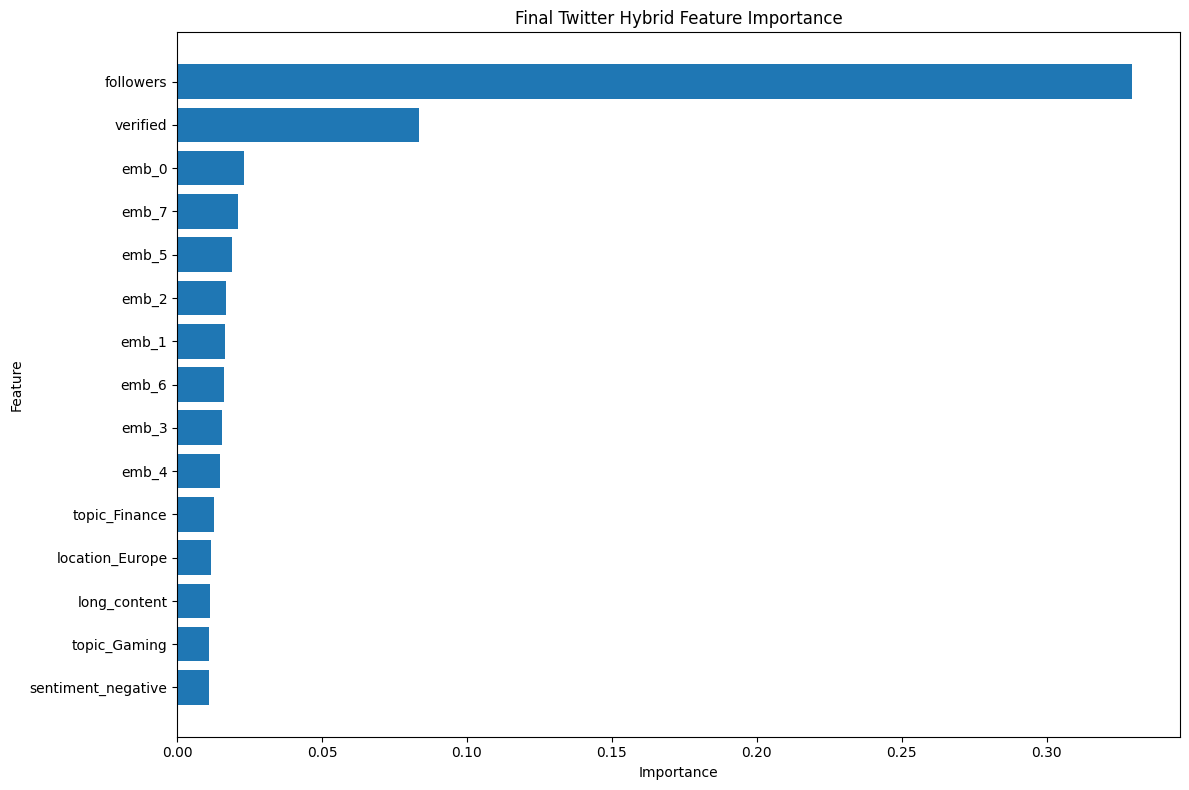

In [125]:
# PLOT FEATURE IMPORTANCE
# =====================================================

top_n = 15

plot_df = importance_df.head(top_n)

plt.figure(figsize=(12, 8))

plt.barh(

    plot_df["feature"][::-1],

    plot_df["importance"][::-1]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title(
    "Final Twitter Hybrid Feature Importance"
)

plt.tight_layout()

plt.show()